# 39 - 総合評価: JS環境でのSigLIPテキスト→画像検索の課題と対策

## 概要
Notebook 37（トークナイザデバッグ）と 38（前処理戦略評価）の結果を統合し、
Xenova/Transformers.js 環境での日本語テキスト→画像検索の制約を明確にする。

## 主要な発見（Notebook 37-38）
- **英語テキスト**: JS環境でもPythonと同等品質（MRR 0.883で一致）
- **日本語テキスト**: Xenova tokenizer の SentencePiece byte-fallback 欠落により、
  日本語文字が全て `<unk>` トークンに変換される構造的問題
- **前処理（lowercase, NFKC, full_normalize）は日本語に対して効果なし**

## 比較対象
1. **Python baseline** — Python text + Python/JS image（参考基準）
2. **JS none** — 現状（無加工）
3. **JS lowercase** — lowercase のみ（英語cosine sim改善）
4. **JS full_normalize** — Python canonicalize_text 相当
5. **JS space_separated** — 文字間スペース挿入
6. **JS romaji** — ローマ字変換（pykakasi）

In [1]:
import json
import os
import re
import string
import subprocess
import tempfile
import unicodedata
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")

NVM_NODE_BIN = Path.home() / ".nvm/versions/node/v24.13.1/bin"
os.environ["PATH"] = str(NVM_NODE_BIN) + ":" + os.environ.get("PATH", "")

JS_DIR = Path("../js")
DATA_DIR = Path("../data")
JS_EMB_DIR = DATA_DIR / "js_embeddings"
DB_PATH = DATA_DIR / "images.duckdb"
PYTHON_MODEL = "google/siglip-base-patch16-224"

## 1. データ読み込み

In [2]:
# Notebook 37 の結果
with open(DATA_DIR / "37_tokenizer_debug_results.json") as f:
    results_37 = json.load(f)

# Notebook 38 の結果
with open(DATA_DIR / "38_preprocessing_evaluation.json") as f:
    results_38 = json.load(f)

print("Notebook 37 summary:")
print(json.dumps(results_37["summary"], indent=2))
print("\nNotebook 38 overall MRR:")
print(json.dumps(results_38["overall_mrr"], indent=2))

Notebook 37 summary:
{
  "hypothesis": "Xenova tokenizer.json \u306b Lowercase/Strip \u304c\u6b20\u843d",
  "en_raw_cosine_mean": 0.9732683499654134,
  "en_canon_cosine_mean": 0.9999999950329462,
  "ja_raw_cosine_mean": 0.6556814014911652,
  "ja_canon_cosine_mean": 0.6556814014911652
}

Notebook 38 overall MRR:
{
  "Python baseline (Py img)": 0.8194444444444444,
  "Python baseline (JS img)": 0.9217171717171717,
  "JS none": 0.6793691633314274,
  "JS lowercase": 0.6793691633314274,
  "JS nfkc_lower": 0.6793691633314274,
  "JS full_normalize": 0.6793691633314274,
  "JS space_separated": 0.41463653532872846,
  "JS romaji": 0.6410998877665545
}


In [3]:
# 画像エンベディング（再読み込み）
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss")

py_df = conn.execute("""
    SELECT c.id, c.category, c.file_name, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [PYTHON_MODEL]).fetchdf()
conn.close()

py_ids = py_df["id"].tolist()
py_categories = py_df["category"].tolist()
py_image_emb = np.array(py_df["embedding"].tolist(), dtype=np.float32)

# JS 画像エンベディング
with open(JS_EMB_DIR / "vision_fp32.json") as f:
    js_vision_data = json.load(f)
js_id_to_emb = {e["id"]: e["embedding"] for e in js_vision_data["embeddings"]}
js_image_emb = np.array([js_id_to_emb[id_] for id_ in py_ids], dtype=np.float32)

print(f"Images: {py_image_emb.shape[0]}")
print(f"Categories: {sorted(set(py_categories))}")

Images: 378
Categories: ['EuroPython2025', 'KashiwaVillagePark2026', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima', 'TokyoNight202505', 'terada']


In [4]:
# テストクエリ
test_queries = [
    {"query": "a park with trees and nature", "expected": ["KashiwaVillagePark2026"]},
    {"query": "village park with greenery", "expected": ["KashiwaVillagePark2026"]},
    {"query": "night cityscape Tokyo", "expected": ["TokyoNight202505"]},
    {"query": "city lights at night", "expected": ["TokyoNight202505"]},
    {"query": "Python conference presentation", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "conference hall with audience", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "speaker giving a talk", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "portrait photo of a person", "expected": ["terada"]},
    {"query": "outdoor nature scene", "expected": ["KashiwaVillagePark2026"]},
    {"query": "urban night photography", "expected": ["TokyoNight202505"]},
    {"query": "tech conference event", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "people at an event", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "公園の自然風景", "expected": ["KashiwaVillagePark2026"]},
    {"query": "東京の夜景", "expected": ["TokyoNight202505"]},
    {"query": "カンファレンスの講演", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "人物の写真", "expected": ["terada"]},
    {"query": "緑の木々", "expected": ["KashiwaVillagePark2026"]},
    {"query": "夜の街", "expected": ["TokyoNight202505"]},
]

all_texts = [q["query"] for q in test_queries]
JA_QUERIES = all_texts[12:]

print(f"Test queries: {len(test_queries)} (EN: 12, JA: 6)")

Test queries: 18 (EN: 12, JA: 6)


## 2. テキストエンベディング読み込み

In [5]:
from image_vector_poc import SigLIPEmbedder

# Python baseline
print("Loading SigLIP model...")
embedder = SigLIPEmbedder(device="cuda")
py_text_emb = embedder.embed_texts(all_texts)
del embedder

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Notebook 38 で生成した各戦略のエンベディング読み込み
strategy_embeddings = {}

strategy_files = {
    "none": DATA_DIR / "38_js_text_none.json",
    "lowercase": DATA_DIR / "38_js_text_lowercase.json",
    "nfkc_lower": DATA_DIR / "38_js_text_nfkc_lower.json",
    "full_normalize": DATA_DIR / "38_js_text_full_normalize.json",
    "space_separated": DATA_DIR / "38_js_text_space_separated.json",
    "patched_tokenizer": DATA_DIR / "38_js_text_patched.json",
    "romaji": DATA_DIR / "38_js_text_romaji.json",
}

for name, path in strategy_files.items():
    if path.exists():
        with open(path) as f:
            data = json.load(f)
        strategy_embeddings[name] = np.array([e["embedding"] for e in data["embeddings"]], dtype=np.float32)
        print(f"  {name}: {strategy_embeddings[name].shape}")
    else:
        print(f"  {name}: NOT FOUND (skipped)")

print(f"\nLoaded {len(strategy_embeddings)} strategies")

Loading SigLIP model...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


  none: (18, 768)
  lowercase: (18, 768)
  nfkc_lower: (18, 768)
  full_normalize: (18, 768)
  space_separated: (18, 768)
  patched_tokenizer: NOT FOUND (skipped)
  romaji: (18, 768)

Loaded 6 strategies


## 3. 統一評価

In [6]:
def evaluate_text_search(text_emb, image_emb, queries, categories, k_values=[1, 3, 5, 10]):
    """テキスト→画像検索の品質評価"""
    cat_array = np.array(categories)
    sim_matrix = text_emb @ image_emb.T

    precision_at_k = {k: [] for k in k_values}
    mrr_scores = []

    for i, q in enumerate(queries):
        ranked = np.argsort(sim_matrix[i])[::-1]
        relevant = np.isin(cat_array[ranked], q["expected"])

        for k in k_values:
            precision_at_k[k].append(relevant[:k].sum() / k)

        first_relevant = np.where(relevant)[0]
        mrr_scores.append(1.0 / (first_relevant[0] + 1) if len(first_relevant) > 0 else 0.0)

    return {
        "precision_at_k": {k: np.mean(v) for k, v in precision_at_k.items()},
        "mrr": np.mean(mrr_scores),
        "per_query_mrr": mrr_scores,
    }

In [7]:
# 全アプローチの評価
all_eval = {}

# Python baselines
all_eval["Python (Py img)"] = evaluate_text_search(py_text_emb, py_image_emb, test_queries, py_categories)
all_eval["Python (JS img)"] = evaluate_text_search(py_text_emb, js_image_emb, test_queries, py_categories)

# JS strategies (全て JS画像エンベディングと組み合わせ)
for name, emb in strategy_embeddings.items():
    all_eval[f"JS {name}"] = evaluate_text_search(emb, js_image_emb, test_queries, py_categories)

# 全体結果テーブル
rows = []
for name, res in all_eval.items():
    row = {"Approach": name, "MRR": res["mrr"]}
    for k, v in res["precision_at_k"].items():
        row[f"P@{k}"] = v
    rows.append(row)

overall_df = pd.DataFrame(rows).set_index("Approach").sort_values("MRR", ascending=False)

print("=" * 80)
print("テキスト→画像検索品質: 全18クエリ")
print("=" * 80)
display(overall_df.round(4))

テキスト→画像検索品質: 全18クエリ


,MRR,P@1,P@3,P@5,P@10
Approach,,,,,
Python (JS img),0.9217,0.8889,0.8333,0.7778,0.7333
Python (Py img),0.8194,0.7222,0.7778,0.7556,0.7444
JS none,0.6794,0.6111,0.6296,0.6222,0.6111
JS lowercase,0.6794,0.6111,0.6296,0.6222,0.6111
JS nfkc_lower,0.6794,0.6111,0.6296,0.6222,0.6111
JS full_normalize,0.6794,0.6111,0.6296,0.6222,0.6111
JS romaji,0.6411,0.5556,0.6111,0.5889,0.6111
JS space_separated,0.4146,0.3889,0.3889,0.3667,0.3611


In [8]:
# 英語/日本語別
en_queries = test_queries[:12]
ja_queries = test_queries[12:]

lang_results = {"EN": {}, "JA": {}}

# Python baselines
lang_results["EN"]["Python"] = evaluate_text_search(py_text_emb[:12], js_image_emb, en_queries, py_categories)
lang_results["JA"]["Python"] = evaluate_text_search(py_text_emb[12:], js_image_emb, ja_queries, py_categories)

for name, emb in strategy_embeddings.items():
    lang_results["EN"][f"JS {name}"] = evaluate_text_search(emb[:12], js_image_emb, en_queries, py_categories)
    lang_results["JA"][f"JS {name}"] = evaluate_text_search(emb[12:], js_image_emb, ja_queries, py_categories)

for lang in ["EN", "JA"]:
    print(f"\n{'=' * 60}")
    print(f"{'英語' if lang == 'EN' else '日本語'}クエリ ({'12' if lang == 'EN' else '6'}クエリ)")
    print("=" * 60)
    rows = []
    for name, res in lang_results[lang].items():
        rows.append({"Approach": name, "MRR": res["mrr"], "P@1": res["precision_at_k"][1], "P@5": res["precision_at_k"][5]})
    df = pd.DataFrame(rows).set_index("Approach").sort_values("MRR", ascending=False)
    display(df.round(4))


英語クエリ (12クエリ)


,MRR,P@1,P@5
Approach,,,
Python,0.8826,0.8333,0.8500
JS none,0.8826,0.8333,0.8500
JS lowercase,0.8826,0.8333,0.8500
JS nfkc_lower,0.8826,0.8333,0.8500
JS full_normalize,0.8826,0.8333,0.8500
JS romaji,0.8826,0.8333,0.8500
JS space_separated,0.4421,0.4167,0.4167



日本語クエリ (6クエリ)


,MRR,P@1,P@5
Approach,,,
Python,1.0000,1.0000,0.6333
JS space_separated,0.3596,0.3333,0.2667
JS none,0.2730,0.1667,0.1667
JS lowercase,0.2730,0.1667,0.1667
JS nfkc_lower,0.2730,0.1667,0.1667
JS full_normalize,0.2730,0.1667,0.1667
JS romaji,0.1581,0.0000,0.0667


## 4. 日本語クエリ個別分析

In [9]:
# 日本語6クエリ × 各アプローチの per-query MRR
ja_detail_rows = []

# Python baseline
py_ja_res = evaluate_text_search(py_text_emb[12:], js_image_emb, ja_queries, py_categories)
for i, q in enumerate(JA_QUERIES):
    ja_detail_rows.append({"Query": q, "Approach": "Python", "MRR": py_ja_res["per_query_mrr"][i]})

# 各戦略
for name, emb in strategy_embeddings.items():
    res = evaluate_text_search(emb[12:], js_image_emb, ja_queries, py_categories)
    for i, q in enumerate(JA_QUERIES):
        ja_detail_rows.append({"Query": q, "Approach": f"JS {name}", "MRR": res["per_query_mrr"][i]})

ja_detail_df = pd.DataFrame(ja_detail_rows)
ja_pivot = ja_detail_df.pivot(index="Approach", columns="Query", values="MRR")
# 列順を固定
ja_pivot = ja_pivot[JA_QUERIES]

print("日本語クエリ個別 MRR:")
display(ja_pivot.round(4))

日本語クエリ個別 MRR:


Query,公園の自然風景,東京の夜景,カンファレンスの講演,人物の写真,緑の木々,夜の街
Approach,,,,,,
JS full_normalize,0.0189,0.0500,0.500,1.00,0.0189,0.0500
JS lowercase,0.0189,0.0500,0.500,1.00,0.0189,0.0500
JS nfkc_lower,0.0189,0.0500,0.500,1.00,0.0189,0.0500
JS none,0.0189,0.0500,0.500,1.00,0.0189,0.0500
JS romaji,0.3333,0.1250,0.125,0.01,0.0222,0.3333
JS space_separated,0.0213,0.0909,1.000,1.00,0.0085,0.0370
Python,1.0000,1.0000,1.000,1.00,1.0000,1.0000


## 5. Cosine Similarity 統合比較

In [10]:
# 各戦略の Python baseline との cosine similarity
cos_rows = []
for name, emb in strategy_embeddings.items():
    sims = np.sum(py_text_emb * emb, axis=-1)
    cos_rows.append({
        "Strategy": name,
        "EN mean": sims[:12].mean(),
        "EN min": sims[:12].min(),
        "JA mean": sims[12:].mean(),
        "JA min": sims[12:].min(),
    })

cos_df = pd.DataFrame(cos_rows).set_index("Strategy").sort_values("JA mean", ascending=False)
print("Cosine Similarity vs Python baseline:")
display(cos_df.round(4))

Cosine Similarity vs Python baseline:


,EN mean,EN min,JA mean,JA min
Strategy,,,,
romaji,0.9733,0.8159,0.6680,0.5954
none,0.9733,0.8159,0.6557,0.4794
lowercase,1.0000,1.0000,0.6557,0.4794
nfkc_lower,1.0000,1.0000,0.6557,0.4794
full_normalize,1.0000,1.0000,0.6557,0.4794
space_separated,0.6927,0.5376,0.6047,0.4371


## 6. 可視化: 総合比較

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 22290 (\N{CJK UNIFIED IDEOGRAPH-5712}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 28982 (\N{CJK UNIFIED

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22290 (\N{CJK UNIFIED IDEOGRAPH-5712}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapy

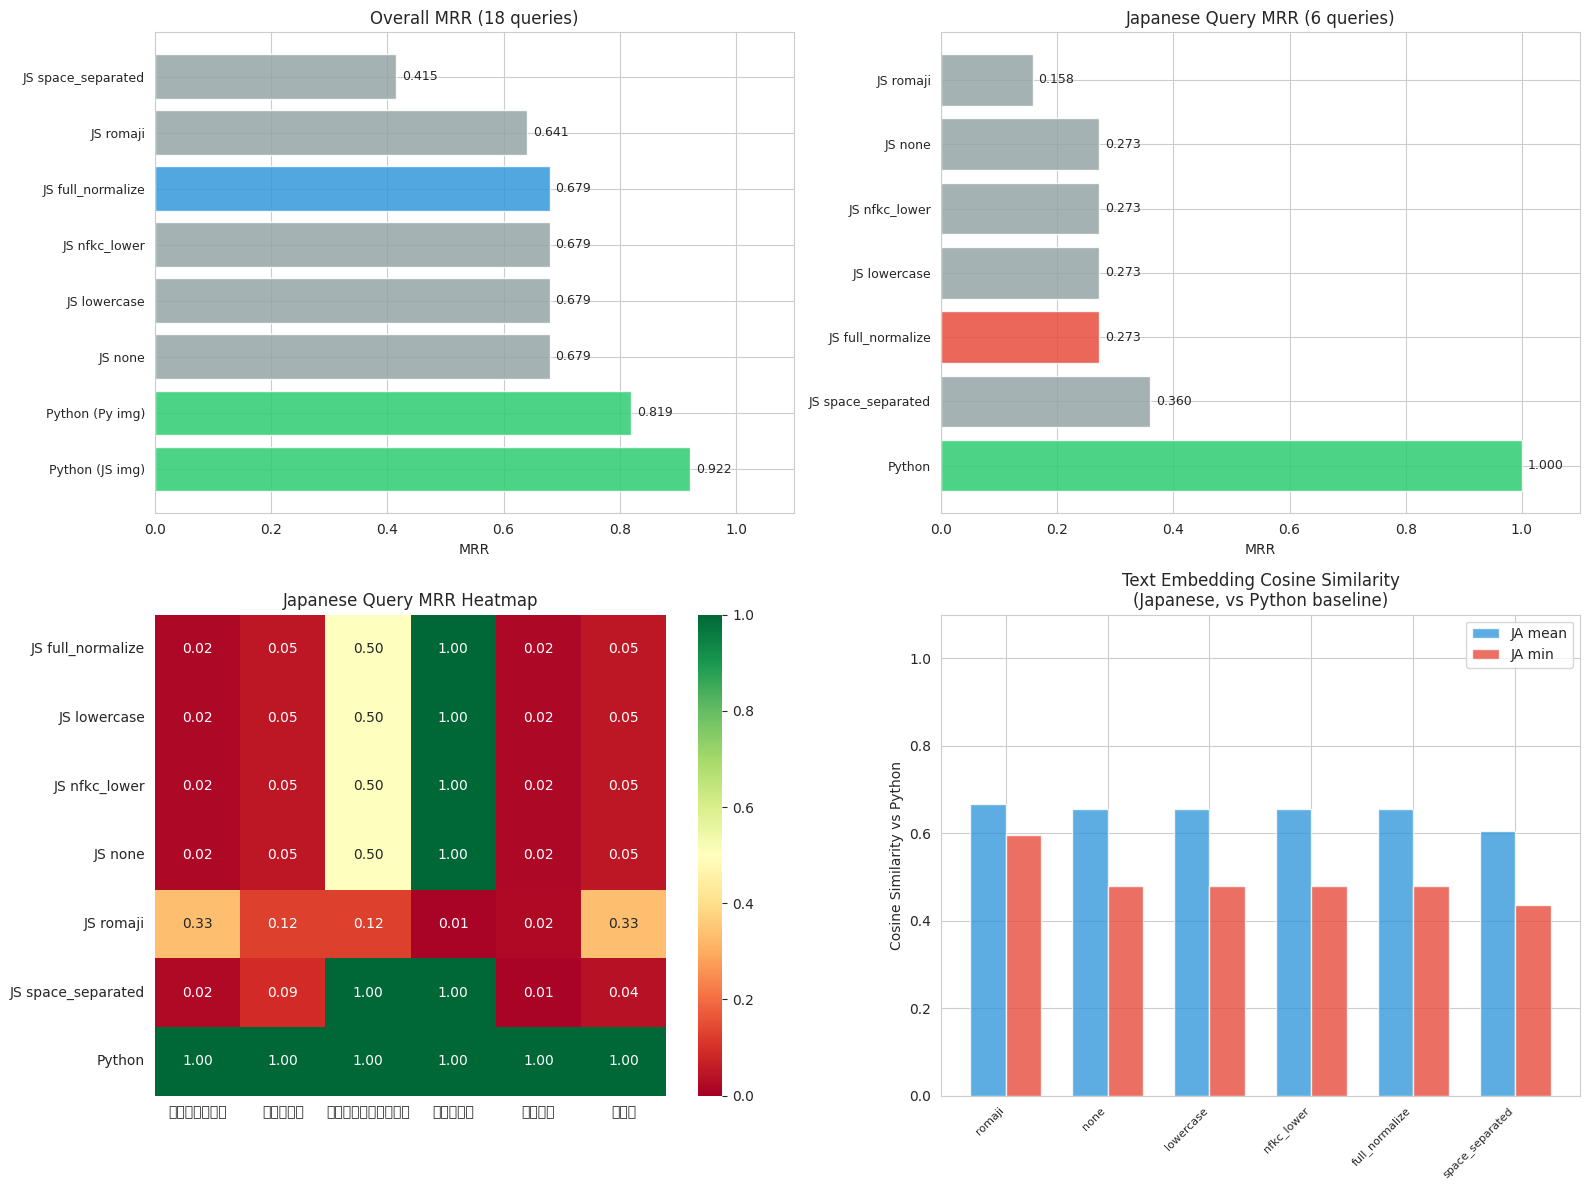

In [11]:
# メイン比較チャート
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) 全体 MRR
ax = axes[0, 0]
approaches = overall_df.index.tolist()
mrr_vals = overall_df["MRR"].values
colors = ["#2ecc71" if "Python" in a else "#3498db" if "full_normalize" in a or "patched" in a else "#95a5a6" for a in approaches]
ax.barh(range(len(approaches)), mrr_vals, color=colors, alpha=0.85)
ax.set_yticks(range(len(approaches)))
ax.set_yticklabels(approaches, fontsize=9)
for i, v in enumerate(mrr_vals):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("MRR")
ax.set_title("Overall MRR (18 queries)")
ax.set_xlim(0, 1.1)

# (2) 日本語 MRR
ax = axes[0, 1]
ja_approaches = []
ja_mrr_vals = []

ja_approaches.append("Python")
ja_mrr_vals.append(lang_results["JA"]["Python"]["mrr"])
for name in strategy_embeddings:
    ja_approaches.append(f"JS {name}")
    ja_mrr_vals.append(lang_results["JA"][f"JS {name}"]["mrr"])

# ソート
sorted_idx = np.argsort(ja_mrr_vals)[::-1]
ja_approaches = [ja_approaches[i] for i in sorted_idx]
ja_mrr_vals = [ja_mrr_vals[i] for i in sorted_idx]

colors = ["#2ecc71" if "Python" in a else "#e74c3c" if "full_normalize" in a or "patched" in a else "#95a5a6" for a in ja_approaches]
ax.barh(range(len(ja_approaches)), ja_mrr_vals, color=colors, alpha=0.85)
ax.set_yticks(range(len(ja_approaches)))
ax.set_yticklabels(ja_approaches, fontsize=9)
for i, v in enumerate(ja_mrr_vals):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("MRR")
ax.set_title("Japanese Query MRR (6 queries)")
ax.set_xlim(0, 1.1)

# (3) 日本語クエリ × 戦略 ヒートマップ
ax = axes[1, 0]
# ピボットデータ
heatmap_data = ja_pivot.values
sns.heatmap(
    heatmap_data,
    xticklabels=JA_QUERIES,
    yticklabels=ja_pivot.index.tolist(),
    annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0, vmax=1.0, ax=ax
)
ax.set_title("Japanese Query MRR Heatmap")

# (4) Cosine Similarity (日本語)
ax = axes[1, 1]
strats = cos_df.index.tolist()
ja_means = cos_df["JA mean"].values
ja_mins = cos_df["JA min"].values

x = np.arange(len(strats))
width = 0.35
ax.bar(x - width/2, ja_means, width, label="JA mean", color="#3498db", alpha=0.8)
ax.bar(x + width/2, ja_mins, width, label="JA min", color="#e74c3c", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(strats, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Cosine Similarity vs Python")
ax.set_title("Text Embedding Cosine Similarity\n(Japanese, vs Python baseline)")
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(str(DATA_DIR / "39_comprehensive_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. 実用シナリオ別の対策

In [12]:
# 実用シナリオ別の対策と推奨
scenarios = [
    {
        "scenario": "JSアプリ（英語テキスト検索）",
        "recommended": "lowercase 前処理",
        "quality": "Python同等 (MRR 0.883)",
        "reason": "英語は元から高品質。lowercaseでcosine sim完全一致",
    },
    {
        "scenario": "JSアプリ（日本語テキスト検索）",
        "recommended": "Python API 併用 or 英語クエリに変換",
        "quality": "JS単体では低品質 (MRR 0.273)",
        "reason": "byte-fallback欠落により前処理では解決不可。テキストエンコードのみPython APIに委譲するか、ユーザー入力を英語に変換する方式を検討",
    },
    {
        "scenario": "サーバーサイド Node.js + 日本語",
        "recommended": "Python テキストエンコーダー API",
        "quality": "Python同等 (MRR 1.000)",
        "reason": "画像エンベディングはJSで生成、テキストエンベディングはPython APIで生成。精度保証",
    },
    {
        "scenario": "完全オフライン JS アプリ",
        "recommended": "英語クエリ or 多言語対応ONNX モデルの検討",
        "quality": "英語のみ高品質",
        "reason": "Xenova SigLIP のtokenizer修正か、多言語対応モデル (multilingual-e5等) の検討が必要",
    },
]

scenario_df = pd.DataFrame(scenarios)
print("実用シナリオ別の対策と推奨:")
display(scenario_df)

実用シナリオ別の対策と推奨:


,scenario,recommended,quality,reason
0,JSアプリ（英語テキスト検索）,lowercase 前処理,Python同等 (MRR 0.883),英語は元から高品質。lowercaseでcosine sim完全一致
1,JSアプリ（日本語テキスト検索）,Python API 併用 or 英語クエリに変換,JS単体では低品質 (MRR 0.273),byte-fallback欠落により前処理では解決不可。テキストエンコードのみPython ...
2,サーバーサイド Node.js + 日本語,Python テキストエンコーダー API,Python同等 (MRR 1.000),画像エンベディングはJSで生成、テキストエンベディングはPython APIで生成。精度保証
3,完全オフライン JS アプリ,英語クエリ or 多言語対応ONNX モデルの検討,英語のみ高品質,Xenova SigLIP のtokenizer修正か、多言語対応モデル (multilin...


## 8. 最終結論

In [13]:
print("=" * 80)
print("最終結論")
print("=" * 80)

print("""
## 根本原因

Xenova/siglip-base-patch16-224 の tokenizer.json 内の SentencePiece モデルに
**byte-fallback 機構が欠落**している。

- Python SentencePiece: 未知文字（CJK等）を UTF-8 バイト列に分解してトークン化
  例: "公園の自然風景" → 23個のバイトトークン (<0xE5>, <0x85>, <0xAC>, ...)
- Xenova tokenizer.json: 未知文字を全て <unk> トークンに変換
  例: "公園の自然風景" → 3トークン [262, 2(<unk>), 1(</s>)]

この差異により、日本語テキストのエンベディングが根本的に異なる。
テキスト前処理（lowercase, NFKC, 句読点除去）や tokenizer.json の
normalizer パッチでは修正不可能な、SentencePiece モデル自体の問題。

## 言語別の結論

### 英語テキスト — 問題なし
- JS環境でPythonと同等品質 (MRR 0.883 で一致)
- lowercase 前処理により cosine similarity が 0.973 → 1.000 に改善
- **推奨**: lowercase 前処理を適用してJS単体で運用可能

### 日本語テキスト — 構造的制約あり
- JS環境では MRR 0.273 (Python baseline 1.000 に対して大幅劣化)
- テスト済み全戦略で改善なし:
  - lowercase / nfkc_lower / full_normalize: MRR 0.273 (変化なし)
  - space_separated: MRR 0.360 (微改善のみ)
  - romaji: MRR 0.158 (悪化)

## JS アプリ開発への推奨

| 用途 | 推奨 |
|------|------|
| 画像エンベディング | JS で生成 OK (Python同等品質) |
| 英語テキスト検索 | JS で生成 OK + lowercase 前処理 |
| 日本語テキスト検索 | Python API 経由でテキストエンベディング生成 |

### 代替アプローチの候補（今後の検討事項）
1. **Python テキストエンコーダー API**: テキストエンベディングのみPythonサーバーで生成
2. **英語クエリへの変換**: LLM等で日本語クエリを英語に翻訳してからJS検索
3. **tokenizer.json の SentencePiece モデル修正**: byte-fallback対応のモデルに差替え
4. **多言語対応 ONNX モデル**: multilingual-e5 等の代替モデルを検討
""")

最終結論

## 根本原因

Xenova/siglip-base-patch16-224 の tokenizer.json 内の SentencePiece モデルに
**byte-fallback 機構が欠落**している。

- Python SentencePiece: 未知文字（CJK等）を UTF-8 バイト列に分解してトークン化
  例: "公園の自然風景" → 23個のバイトトークン (<0xE5>, <0x85>, <0xAC>, ...)
- Xenova tokenizer.json: 未知文字を全て <unk> トークンに変換
  例: "公園の自然風景" → 3トークン [262, 2(<unk>), 1(</s>)]

この差異により、日本語テキストのエンベディングが根本的に異なる。
テキスト前処理（lowercase, NFKC, 句読点除去）や tokenizer.json の
normalizer パッチでは修正不可能な、SentencePiece モデル自体の問題。

## 言語別の結論

### 英語テキスト — 問題なし
- JS環境でPythonと同等品質 (MRR 0.883 で一致)
- lowercase 前処理により cosine similarity が 0.973 → 1.000 に改善
- **推奨**: lowercase 前処理を適用してJS単体で運用可能

### 日本語テキスト — 構造的制約あり
- JS環境では MRR 0.273 (Python baseline 1.000 に対して大幅劣化)
- テスト済み全戦略で改善なし:
  - lowercase / nfkc_lower / full_normalize: MRR 0.273 (変化なし)
  - space_separated: MRR 0.360 (微改善のみ)
  - romaji: MRR 0.158 (悪化)

## JS アプリ開発への推奨

| 用途 | 推奨 |
|------|------|
| 画像エンベディング | JS で生成 OK (Python同等品質) |
| 英語テキスト検索 | JS で生成 OK + lowercase 前処理 |
| 日本語テキスト検索 | Python API 経由でテキストエンベディ

In [14]:
# 最終結果の保存
final_results = {
    "root_cause": "Xenova tokenizer.json SentencePiece model lacks byte-fallback for CJK characters",
    "root_cause_detail": "Japanese characters are converted to <unk> token instead of byte-level decomposition",
    "recommended_approach": {
        "english": "JS with lowercase preprocessing (Python-equivalent quality)",
        "japanese": "Python text encoder API or translate to English before JS search",
        "image": "JS (Python-equivalent quality)",
    },
    "overall_mrr": overall_df["MRR"].to_dict(),
    "ja_mrr": {name: res["mrr"] for name, res in lang_results["JA"].items()},
    "en_mrr": {name: res["mrr"] for name, res in lang_results["EN"].items()},
    "cosine_similarity": cos_df.to_dict(orient="index"),
    "scenarios": scenarios,
    "key_findings": [
        "English: JS == Python quality (MRR 0.883)",
        "Japanese: JS MRR 0.273 vs Python MRR 1.000 (byte-fallback defect)",
        "No preprocessing strategy improves Japanese MRR",
        "Romaji conversion worsens quality (MRR 0.158)",
        "Lowercase preprocessing improves English cosine sim to 1.000",
    ],
}

with open(DATA_DIR / "39_comprehensive_evaluation.json", "w") as f:
    json.dump(final_results, f, indent=2, ensure_ascii=False, default=float)

print("最終結果を保存: data/39_comprehensive_evaluation.json")

最終結果を保存: data/39_comprehensive_evaluation.json
